In [1]:
import pandas as pd
import numpy as np

In [2]:
data=pd.read_csv("loan_approval.csv")
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
data.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N


In [4]:
data.shape

(614, 13)

In [5]:
data.duplicated().sum()

np.int64(0)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [7]:
data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [8]:
data.isnull().sum()*100/len(data)

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [9]:
data=data.drop("Loan_ID",axis=1)

In [10]:
data.head(1)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y


In [11]:
data=data.dropna(subset=["Gender","Married","Dependents","LoanAmount","Loan_Amount_Term"])
data.shape

(553, 12)

In [12]:
data.isnull().sum()*100/len(data)

Gender               0.000000
Married              0.000000
Dependents           0.000000
Education            0.000000
Self_Employed        5.424955
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           0.000000
Loan_Amount_Term     0.000000
Credit_History       8.679928
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [13]:
data["Self_Employed"].dtype

dtype('O')

In [14]:
data["Self_Employed"].mode()[0]

'No'

In [15]:
data["Self_Employed"]=data["Self_Employed"].fillna(data["Self_Employed"].mode()[0])

In [16]:
data["Credit_History"].unique()

array([ 1.,  0., nan])

In [17]:
data["Credit_History"].mode()[0]

np.float64(1.0)

In [18]:
data["Credit_History"]=data["Credit_History"].fillna(data["Credit_History"].mode()[0])

In [19]:
data.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [20]:
data.sample(5)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
214,Male,Yes,0,Graduate,No,3173,3021.0,137.0,360.0,1.0,Urban,Y
331,Male,No,0,Graduate,No,2935,0.0,98.0,360.0,1.0,Semiurban,Y
378,Male,No,0,Graduate,No,3069,0.0,71.0,480.0,1.0,Urban,N
308,Male,No,0,Graduate,No,20233,0.0,480.0,360.0,1.0,Rural,N
556,Female,No,0,Graduate,No,2667,1625.0,84.0,360.0,1.0,Urban,Y


In [21]:
data['Dependents'].unique()

array(['1', '0', '2', '3+'], dtype=object)

In [22]:
data['Dependents']=data['Dependents'].replace("3+",'3')
data['Dependents'].unique()

array(['1', '0', '2', '3'], dtype=object)

In [23]:
data.sample(5)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
381,Male,No,0,Graduate,No,5941,4232.0,296.0,360.0,1.0,Semiurban,Y
119,Female,No,0,Graduate,No,10408,0.0,259.0,360.0,1.0,Urban,Y
53,Male,Yes,2,Graduate,No,4616,0.0,134.0,360.0,1.0,Urban,N
147,Male,Yes,1,Graduate,No,1538,1425.0,30.0,360.0,1.0,Urban,Y
440,Male,No,0,Graduate,No,3660,5064.0,187.0,360.0,1.0,Semiurban,Y


In [24]:
data["Gender"].unique()

array(['Male', 'Female'], dtype=object)

In [25]:
data["Gender"]=data["Gender"].map({"Female":0,"Male":1})

In [26]:
data["Gender"].unique()

array([1, 0])

In [27]:
data["Married"].unique()

array(['Yes', 'No'], dtype=object)

In [28]:
data["Married"]=data["Married"].map({"No":0,"Yes":1})

In [29]:
data["Married"].unique()

array([1, 0])

In [30]:
data["Education"].unique()

array(['Graduate', 'Not Graduate'], dtype=object)

In [31]:
data["Education"]=data["Education"].map({'Not Graduate':0,'Graduate':1})

In [32]:
data["Education"].unique()

array([1, 0])

In [33]:
data['Self_Employed'].unique()

array(['No', 'Yes'], dtype=object)

In [34]:
data["Self_Employed"]=data["Self_Employed"].map({"No":0,"Yes":1})

In [35]:
data['Self_Employed'].unique()

array([0, 1])

In [36]:
data['Property_Area'].unique()

array(['Rural', 'Urban', 'Semiurban'], dtype=object)

In [37]:
data['Property_Area']=data['Property_Area'].map({'Rural':0,'Semiurban':1,'Urban':2})

In [38]:
data['Loan_Status'].unique()

array(['N', 'Y'], dtype=object)

In [39]:
data['Loan_Status']=data['Loan_Status'].map({'N':0,'Y':1})

In [40]:
data.head(2)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1


In [41]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 553 entries, 1 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             553 non-null    int64  
 1   Married            553 non-null    int64  
 2   Dependents         553 non-null    object 
 3   Education          553 non-null    int64  
 4   Self_Employed      553 non-null    int64  
 5   ApplicantIncome    553 non-null    int64  
 6   CoapplicantIncome  553 non-null    float64
 7   LoanAmount         553 non-null    float64
 8   Loan_Amount_Term   553 non-null    float64
 9   Credit_History     553 non-null    float64
 10  Property_Area      553 non-null    int64  
 11  Loan_Status        553 non-null    int64  
dtypes: float64(4), int64(7), object(1)
memory usage: 56.2+ KB


In [42]:
data['Dependents']=data['Dependents'].astype('int')

In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 553 entries, 1 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             553 non-null    int64  
 1   Married            553 non-null    int64  
 2   Dependents         553 non-null    int64  
 3   Education          553 non-null    int64  
 4   Self_Employed      553 non-null    int64  
 5   ApplicantIncome    553 non-null    int64  
 6   CoapplicantIncome  553 non-null    float64
 7   LoanAmount         553 non-null    float64
 8   Loan_Amount_Term   553 non-null    float64
 9   Credit_History     553 non-null    float64
 10  Property_Area      553 non-null    int64  
 11  Loan_Status        553 non-null    int64  
dtypes: float64(4), int64(8)
memory usage: 56.2 KB


In [44]:
X=data.drop('Loan_Status',axis=1)
y=data['Loan_Status']

In [45]:
X.head(2)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,2


In [46]:
y

1      0
2      1
3      1
4      1
5      1
      ..
609    1
610    1
611    1
612    1
613    0
Name: Loan_Status, Length: 553, dtype: int64

In [47]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [48]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=5,stratify=y)

In [49]:
from sklearn.linear_model import LogisticRegression

In [50]:
model=Pipeline([('scaler',StandardScaler()),('classifier',LogisticRegression())])
model.fit(X_train,y_train)

LR_Train_Acc=model.score(X_train,y_train)
LR_Test_Acc=model.score(X_test,y_test)
print("LogisticRegression Training Score--",LR_Train_Acc)
print("LogisticRegression Testing Score--",LR_Test_Acc)

LR_cv_score=np.mean(cross_val_score(model,X,y,cv=5))
print(f"Cross validation Average score--{LR_cv_score}")


LogisticRegression Training Score-- 0.8054298642533937
LogisticRegression Testing Score-- 0.8198198198198198
Cross validation Average score--0.802964782964783


In [51]:
from sklearn.neighbors import KNeighborsClassifier

In [52]:
model=Pipeline([('scaler',StandardScaler()),('classifier',KNeighborsClassifier())])
model.fit(X_train,y_train)

KN_Train_Acc=model.score(X_train,y_train)
KN_Test_Acc=model.score(X_test,y_test)
print("KNeighborsClassifier Training Score--",KN_Train_Acc)
print("KNeighborsClassifier Testing Score--",KN_Test_Acc)

KN_cv_score=np.mean(cross_val_score(model,X,y,cv=5))
print(f"Cross validation Average score--{KN_cv_score}")


KNeighborsClassifier Training Score-- 0.8099547511312217
KNeighborsClassifier Testing Score-- 0.8108108108108109
Cross validation Average score--0.7757411957411958


In [53]:
from sklearn.tree import DecisionTreeClassifier

In [54]:

model=DecisionTreeClassifier()
model.fit(X_train,y_train)

DT_Train_Acc=model.score(X_train,y_train)
DT_Test_Acc=model.score(X_test,y_test)
print("DecisionTreeClassifier Training Score--",DT_Train_Acc)
print("DecisionTreeClassifier Testing Score--",DT_Test_Acc)

DT_cv_score=np.mean(cross_val_score(model,X,y,cv=5))
print(f"Cross validation Average score--{DT_cv_score}")


DecisionTreeClassifier Training Score-- 1.0
DecisionTreeClassifier Testing Score-- 0.6936936936936937
Cross validation Average score--0.7124488124488124


In [55]:
from sklearn.ensemble import RandomForestClassifier

In [56]:
model=RandomForestClassifier()
model.fit(X_train,y_train)

RF_Train_Acc=model.score(X_train,y_train)
RF_Test_Acc=model.score(X_test,y_test)
print("RandomForestClassifier Training Score--",RF_Train_Acc)
print("RandomForestClassifier Testing Score--",RF_Test_Acc)

RF_cv_score=np.mean(cross_val_score(model,X,y,cv=5))
print(f"Cross validation Average score--{RF_cv_score}")


RandomForestClassifier Training Score-- 1.0
RandomForestClassifier Testing Score-- 0.7927927927927928
Cross validation Average score--0.7884848484848483


In [57]:
from sklearn.svm import SVC

In [58]:
model=Pipeline([('scaler',StandardScaler()),('classifier',SVC())])
model.fit(X_train,y_train)

SVC_Train_Acc=model.score(X_train,y_train)
SVC_Test_Acc=model.score(X_test,y_test)
print("Support Vector Classifier Training Score--",SVC_Train_Acc)
print("Support Vector Classifier Testing Score--",SVC_Test_Acc)

SVC_cv_score=np.mean(cross_val_score(model,X,y,cv=5))
print(f"Cross validation Average score--{SVC_cv_score}")


Support Vector Classifier Training Score-- 0.8144796380090498
Support Vector Classifier Testing Score-- 0.8108108108108109
Cross validation Average score--0.8011302211302211


In [59]:
from sklearn.ensemble import GradientBoostingClassifier

In [60]:
model=GradientBoostingClassifier()
model.fit(X_train,y_train)

GBC_Train_Acc=model.score(X_train,y_train)
GBC_Test_Acc=model.score(X_test,y_test)
print("GradientBoostingClassifier Training Score--",GBC_Train_Acc)
print("GradientBoostingClassifier Testing Score--",GBC_Test_Acc)

GBC_cv_score=np.mean(cross_val_score(model,X,y,cv=5))
print(f"Cross validation Average score--{GBC_cv_score}")


GradientBoostingClassifier Training Score-- 0.9049773755656109
GradientBoostingClassifier Testing Score-- 0.7927927927927928
Cross validation Average score--0.7703521703521703


In [61]:
final_data=pd.DataFrame({
'Models':['LogisticRegression','KNeighborsClassifier','DecisionTreeClassifier','RandomForestClassifier','SVC','GradientBoostingClassifier'],
'Training_Accuracy':[LR_Train_Acc,KN_Train_Acc,DT_Train_Acc,RF_Train_Acc,SVC_Train_Acc,GBC_Train_Acc],
'Testing _Accuracy':[LR_Test_Acc,KN_Test_Acc,DT_Test_Acc,RF_Test_Acc,SVC_Test_Acc,GBC_Test_Acc],
'Cross_validation_Score':[LR_cv_score,KN_cv_score,DT_cv_score,RF_cv_score,SVC_cv_score,GBC_cv_score]
})
final_data

,Models,Training_Accuracy,Testing _Accuracy,Cross_validation_Score
0,LogisticRegression,0.805430,0.819820,0.802965
1,KNeighborsClassifier,0.809955,0.810811,0.775741
2,DecisionTreeClassifier,1.000000,0.693694,0.712449
3,RandomForestClassifier,1.000000,0.792793,0.788485
4,SVC,0.814480,0.810811,0.801130
5,GradientBoostingClassifier,0.904977,0.792793,0.770352


In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

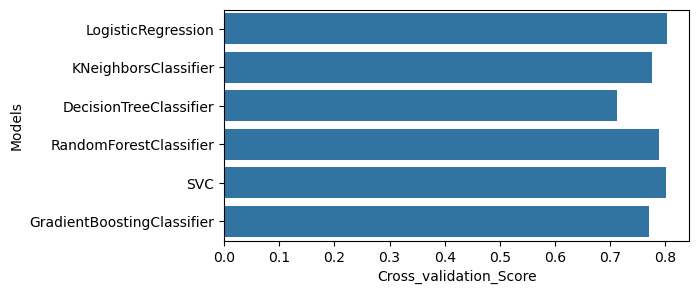

In [63]:
plt.figure(figsize=(6,3))
sns.barplot(y='Models',x='Cross_validation_Score',data=final_data)
plt.show()

In [64]:
import joblib

In [65]:
X.shape

(553, 11)

In [66]:
y.shape

(553,)

In [67]:
Final_Model=Pipeline([('scaler',StandardScaler()),('classifier',LogisticRegression())])
Final_Model.fit(X,y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LogisticRegression())])

In [68]:
joblib.dump(Final_Model,'Loan_Approval_Prediction_Model.pkl')

['Loan_Approval_Prediction_Model.pkl']

In [69]:
df=pd.DataFrame({
    'Gender':1,             
    'Married':1,            
    'Dependents':2,
    'Education':0,
    'Self_Employed':0,
    'ApplicantIncome':2889,
    'CoapplicantIncome':0.0,
    'LoanAmount':45,
    'Loan_Amount_Term':180,
    'Credit_History':0,
    'Property_Area':1 
},index=[0])
df


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,1,2,0,0,2889,0.0,45,180,0,1


In [70]:

model=joblib.load('Loan_Approval_Prediction_Model.pkl')
result=model.predict(df)
result

array([0])

In [71]:
if result[0]==1:
    print('Loan Approved')
else:
    print('Loan Not Approved')

Loan Not Approved


In [72]:
from tkinter import *
import joblib

In [73]:
model=joblib.load('Loan_Approval_Prediction_Model.pkl')
def show_entry():
    try:
        p1=float(e1.get())
        p2=float(e2.get())
        p3=float(e3.get())
        p4=float(e4.get())
        p5=float(e5.get())
        p6=float(e6.get())
        p7=float(e7.get())
        p8=float(e8.get())
        p9=float(e9.get())
        p10=float(e10.get())
        p11=float(e11.get())
        
        df=pd.DataFrame({
            'Gender':p1,             
            'Married':p2,            
            'Dependents':p3,
            'Education':p4,
            'Self_Employed':p5,
            'ApplicantIncome':p6,
            'CoapplicantIncome':p7,
            'LoanAmount':p8,
            'Loan_Amount_Term':p9,
            'Credit_History':p10,
            'Property_Area':p11
        },index=[0])

        result=model.predict(df)
        
        if result[0]==1:
            result_label.config(text="Loan Approved",fg='green')
        else:
            result_label.config(text="Loan Not Approved",fg='red')

        # Clear all input fields after prediction
        for entry in [e1,e2,e3,e4,e5,e6,e7,e8,e9,e10,e11]:
            entry.delete(0, END)

    except ValueError:
        result_label.config(text="Please enter valid values in all fields",fg="red")
        
    except Exception as e:
        result_label.config(text=f"Error: {e}",fg="red")

master=Tk()

master.title("Loan Approval Prediction")
master.geometry("600x650")
master.configure(bg='#f2f2f2')
master.columnconfigure(0, weight=1)
master.columnconfigure(1, weight=1)

label=Label(master,text="Loan Approval Prediction",bg='#1f4e78',fg='white',font=("Arial",18,"bold"),
    pady=10)
label.grid(row=0,column=0,columnspan=2,pady=10)

Label(master,text="Gender [1: Male, 0: Female]",bg='#f2f2f2',font=("Arial",10,"bold")).grid(row=1,padx=10,pady=5)
Label(master,text="Married [1: Yes, 0: No]",bg='#f2f2f2',font=("Arial",10,"bold")).grid(row=2,padx=10,pady=5)
Label(master,text="Dependents [0,1,2,3]",bg='#f2f2f2',font=("Arial",10,"bold")).grid(row=3,padx=10,pady=5)
Label(master,text="Education [0: 'Not Graduate', 1: 'Graduate']",bg='#f2f2f2',font=("Arial",10,"bold")).grid(row=4,padx=10,pady=5)
Label(master,text="Self_Employed [0: 'No', 1: 'Yes']",bg='#f2f2f2',font=("Arial",10,"bold")).grid(row=5,padx=10,pady=5)
Label(master,text="ApplicantIncome",bg='#f2f2f2',font=("Arial",10,"bold")).grid(row=6,padx=10,pady=5)
Label(master,text="CoapplicantIncome",bg='#f2f2f2',font=("Arial",10,"bold")).grid(row=7,padx=10,pady=5)
Label(master,text="LoanAmount",bg='#f2f2f2',font=("Arial",10,"bold")).grid(row=8,padx=10,pady=5)
Label(master,text="Loan_Amount_Term",bg='#f2f2f2',font=("Arial",10,"bold")).grid(row=9,padx=10,pady=5)
Label(master,text="Credit_History",bg='#f2f2f2',font=("Arial",10,"bold")).grid(row=10,padx=10,pady=5)
Label(master,text="Property_Area [0: 'Rural', 1: 'Semiurban', 2: 'Urban']",bg='#f2f2f2',font=("Arial",10,"bold")).grid(row=11,padx=10,pady=5)

e1=Entry(master,width=25)
e2=Entry(master,width=25)
e3=Entry(master,width=25)
e4=Entry(master,width=25)
e5=Entry(master,width=25)
e6=Entry(master,width=25)
e7=Entry(master,width=25)
e8=Entry(master,width=25)
e9=Entry(master,width=25)
e10=Entry(master,width=25)
e11=Entry(master,width=25)

e1.grid(row=1,column=1,padx=10,pady=5)
e2.grid(row=2,column=1,padx=10,pady=5)
e3.grid(row=3,column=1,padx=10,pady=5)
e4.grid(row=4,column=1,padx=10,pady=5)
e5.grid(row=5,column=1,padx=10,pady=5)
e6.grid(row=6,column=1,padx=10,pady=5)
e7.grid(row=7,column=1,padx=10,pady=5)
e8.grid(row=8,column=1,padx=10,pady=5)
e9.grid(row=9,column=1,padx=10,pady=5)
e10.grid(row=10,column=1,padx=10,pady=5)
e11.grid(row=11,column=1,padx=10,pady=5)



Button(master,text="Predict",command=show_entry,bg="#1f4e78",fg="white",font=("Arial",12,"bold"),width=15).grid(row=12,column=0,columnspan=2,pady=20)

result_label=Label(master,text="",bg="#f2f2f2",font=("Arial",14,"bold"))
result_label.grid(row=13,column=0,columnspan=2,pady=10)

mainloop()